# Choosing the sharp inversion (IRLS) parameters

The IRLS solver introduced in the [recovering sharp features notebook](recovering_sharp_features.ipynb) has three parameters:

- `sharpness_weight` ($\beta$): the trade-off between fitting the gravity data and penalizing the model's gradients. This is by far the most important parameter: too low and the inversion behaves as if unregularized, fitting noise with rough artifacts; too high and it can't fit the data at all (and takes many more iterations trying, since each step is held back by the penalty).
- `sharpness_norm` ($p$): the norm of the gradient penalty. 1 (the default) is the L1 / total variation penalty which favors sharp steps, values below 1 are even sparser, and 2 reverts to a smooth L2 penalty.
- `irls_epsilon` ($\epsilon$): the small value stabilizing the reweighting for flat gradients. It rarely needs tuning, as long as it stays small compared to the real cell-to-cell relief of the surface.

These are *hyperparameters*: the data alone cannot choose them, so we choose them by **cross-validation**, exactly as done for the damping parameter in the [damping cross-validation tutorial](../tutorial/04_damping_cross_validation.ipynb).
This notebook uses the new [optimize_inversion_sharpness](../api/generated/invert4geom.Inversion.optimize_inversion_sharpness.rst) method, which supports two scoring strategies:

1. a **gravity holdout**: the gravity data are split into training and testing points, the inversion runs on the training points only, and each parameter set is scored by how well the inverted model predicts the held-out testing gravity;
2. **constraint points**: if points of known topography are available (wells, outcrops), each parameter set is instead scored by the misfit between them and the inverted surface.

We demonstrate both, on the zigzag-fault synthetic from the [recovering sharp features notebook](recovering_sharp_features.ipynb).

## Import packages

In [1]:
import copy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import verde as vd

import invert4geom

## Create the synthetic data

The same faulted basement as the [recovering sharp features notebook](recovering_sharp_features.ipynb): a 600 m zigzag fault scarp with gentle background undulations, forward calculated and contaminated with 0.1 mGal of noise, and a flat starting model at the reference level.
We use a 1 km grid spacing to keep each of the many cross-validation inversions fast.

In [2]:
spacing = 1000
region = (0, 40000, 0, 30000)

grid_coords = vd.grid_coordinates(spacing=spacing, region=region)
easting, northing = grid_coords

# zigzag fault trace: straight segments between these corner points
fault_knots_northing = [0, 10000, 20000, 30000]
fault_knots_easting = [18000, 22000, 18000, 22000]
fault_easting = np.interp(northing, fault_knots_northing, fault_knots_easting)

# 600 m vertical offset across the fault, plus smooth undulations
basement = np.where(easting < fault_easting, -800.0, -200.0)
basement += 60 * np.sin(easting / 5e3) * np.cos(northing / 7e3)

true_topography = vd.make_xarray_grid(
    grid_coords,
    data=basement,
    data_names="upward",
).upward

zref = -500
density_contrast = 400

true_model = invert4geom.create_model(
    zref=zref,
    density_contrast=density_contrast,
    topography=true_topography.to_dataset(),
)

observed_gravity = vd.make_xarray_grid(
    grid_coords,
    data=(np.zeros_like(easting), np.full_like(easting, 1000.0)),
    data_names=("gravity_anomaly", "upward"),
)
data = invert4geom.create_data(observed_gravity)
data.inv.forward_gravity(true_model, progressbar=False)

gravity_noise = 0.1
data["gravity_anomaly"], _ = invert4geom.synthetic.contaminate(
    data.forward_gravity,
    stddev=gravity_noise,
    seed=0,
)

starting_topography = vd.make_xarray_grid(
    grid_coords,
    data=np.full_like(easting, zref),
    data_names="upward",
)
starting_model = invert4geom.create_model(
    zref=zref,
    density_contrast=density_contrast,
    topography=starting_topography,
)
data.inv.forward_gravity(starting_model, progressbar=False)
data.inv.regional_separation(method="constant", constant=0)

## Split the gravity into training and testing points

For the gravity holdout scoring we add a set of testing points with [add_test_points](../api/generated/invert4geom.add_test_points.rst), which resamples the data so that alternating points are flagged as `test`.
During each trial the inversion only sees the training points; the score is the RMSE between the held-out testing gravity and the forward gravity of the inverted model at those points.

In [3]:
inv = invert4geom.Inversion(
    copy.deepcopy(data),
    copy.deepcopy(starting_model),
    solver_type="irls",
    sharpness_weight=0.01,  # starting value, to be optimized
    max_iterations=100,
    l2_norm_tolerance=np.sqrt(gravity_noise),
    delta_l2_norm_tolerance=1.001,
)

# add a train/test split to the gravity data
inv.data = invert4geom.add_test_points(inv.data)
inv.data

<xarray.Dataset> Size: 401kB
Dimensions:                   (northing: 61, easting: 81)
Coordinates:
  * northing                  (northing) float64 488B 0.0 500.0 ... 3e+04
  * easting                   (easting) float64 648B 0.0 500.0 ... 4e+04
Data variables:
    test                      (northing, easting) bool 5kB False True ... False
    gravity_anomaly           (northing, easting) float64 40kB -1.603 ... 1.706
    upward                    (northing, easting) float64 40kB 1e+03 ... 1e+03
    forward_gravity           (northing, easting) float64 40kB 0.0 0.0 ... 0.0
    misfit                    (northing, easting) float64 40kB -1.603 ... 1.706
    reg                       (northing, easting) float64 40kB 0.0 0.0 ... 0.0
    res                       (northing, easting) float64 40kB -1.603 ... 1.706
    starting_forward_gravity  (northing, easting) float64 40kB 0.0 0.0 ... 0.0
    starting_misfit           (northing, easting) float64 40kB -1.603 ... 1.706
    starting_reg              (northing, easting) float64 40kB 0.0 0.0 ... 0.0
    starting_res              (northing, easting) float64 40kB -1.603 ... 1.706
Attributes:
    region:        (0.0, 40000.0, 0.0, 30000.0)
    spacing:       1000.0
    buffer_width:  3000.0
    inner_region:  (3000.0, 37000.0, 3000.0, 27000.0)
    dataset_type:  data
    model_type:    prisms
    coord_names:   ('easting', 'northing')

## Cross-validation for the sharpness weight

The sharpness weight spans orders of magnitude, so we search it in log space.
A grid search over 12 values between 10$^{-4}$ and 10$^{-1}$ shows the classic cross-validation curve: the score is poor when the inversion is under-regularized (left side, fitting noise at the testing points) and again when it is over-regularized (right side, too blocky to reproduce the anomaly), with a minimum in between.

  0%|          | 0/12 [00:00<?, ?it/s]

best sharpness_weight: 1.23e-03


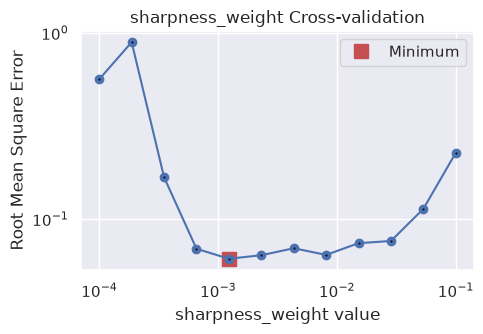

In [4]:
inv_best = inv.optimize_inversion_sharpness(
    n_trials=12,
    sharpness_weight_limits=(1e-4, 1e-1),
    grid_search=True,
    fname="tmp/sharpness_cv_weight",
    plot_scores=True,
    progressbar=True,
)

best_weight = inv_best.best_trial.params["sharpness_weight"]
print(f"best sharpness_weight: {best_weight:.2e}")

## What the score is measuring

To see what the cross-validation is trading off, we run the full inversion with a much smaller weight, the optimal weight, and a much larger weight, and compare the recovered surfaces on a profile across the fault.
The under-regularized surface oscillates by *thousands* of meters, running far off the plot's scale, while the over-regularized one is stable but rounds off and displaces the fault step.

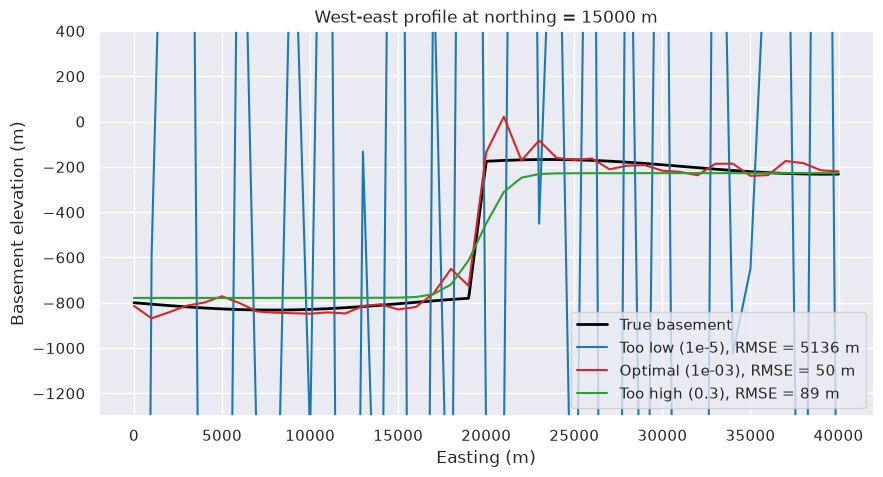

In [5]:
weights = {
    "Too low (1e-5)": 1e-5,
    f"Optimal ({best_weight:.0e})": best_weight,
    "Too high (0.3)": 0.3,
}

recovered = {}
for name, weight in weights.items():
    trial_inv = invert4geom.Inversion(
        copy.deepcopy(data),
        copy.deepcopy(starting_model),
        solver_type="irls",
        sharpness_weight=weight,
        max_iterations=100,
        l2_norm_tolerance=np.sqrt(gravity_noise),
        delta_l2_norm_tolerance=1.001,
    )
    trial_inv.invert(progressbar=False)
    recovered[name] = trial_inv.model.topography

profile_northing = 15000

fig, ax = plt.subplots(figsize=(10, 5))
true_topography.sel(northing=profile_northing).plot(
    ax=ax, color="black", lw=2, label="True basement"
)
for (name, topo), color in zip(
    recovered.items(), ["tab:blue", "tab:red", "tab:green"], strict=True
):
    rmse = float(np.sqrt(np.mean((topo.values - true_topography.values) ** 2)))
    topo.sel(northing=profile_northing).plot(
        ax=ax, color=color, lw=1.5, label=f"{name}, RMSE = {rmse:.0f} m"
    )
ax.set_ylim(-1300, 400)
ax.set_title(f"West-east profile at northing = {profile_northing} m")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Basement elevation (m)")
ax.legend(loc="lower right")
plt.show()

## Jointly optimizing the sharpness weight and norm

More than one parameter can be optimized at once by supplying limits for each; without a grid search, Optuna's sampler explores the joint space.
Here we optimize `sharpness_weight` and `sharpness_norm` together, letting the data decide how sharp the regularization should be.

```{note}
Watch what happens: even though the true surface is dominated by a sharp fault, the optimization drifts towards a norm of 2 (a smooth penalty) with a very small weight.
This is not a failure of the optimizer, it is the non-uniqueness of gravity at work: smooth and sharp models predict the held-out gravity equally well, so the score surface is nearly flat in the norm direction and the "best" norm is decided by noise.
A gravity holdout cannot tell you how sharp the geology is; the norm is better treated as a *geological prior* (fix it at 1 if you expect faults, 2 if you expect smooth surfaces), or chosen with constraint-point scoring as in the next section, which measures the accuracy of the recovered surface itself.
```

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

best parameters: {'sharpness_weight': 0.0002985336168408363, 'sharpness_norm': 2.308149165742039}


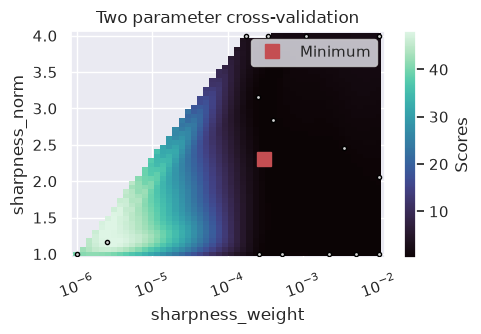

In [6]:
inv2 = invert4geom.Inversion(
    copy.deepcopy(data),
    copy.deepcopy(starting_model),
    solver_type="irls",
    sharpness_weight=0.01,
    max_iterations=100,
    l2_norm_tolerance=np.sqrt(gravity_noise),
    delta_l2_norm_tolerance=1.001,
)
inv2.data = invert4geom.add_test_points(inv2.data)

inv2_best = inv2.optimize_inversion_sharpness(
    n_trials=16,
    sharpness_weight_limits=(1e-6, 1e-2),
    sharpness_norm_limits=(1.0, 4.0),
    fname="tmp/sharpness_cv_weight_norm",
    plot_scores=True,
    logy=False,
    progressbar=True,
)

print("best parameters:", inv2_best.best_trial.params)

## Scoring with constraint points instead

When points of known topography are available (boreholes, outcrops, seismic picks), they can score the trials directly: pass them as `constraints_df` and each trial is scored by the RMSE between the constraint elevations and the inverted surface, with no train/test split of the gravity needed.

As with the [density contrast cross-validation](fault_bounded_basin.ipynb), the inversion must **not** enforce these constraints (no weighting grid or mask) during the optimization, or the score would be insensitive to the parameters.
Here we sample 15 pseudo-random points of the true basement to act as our known points, and search a wider range of weights.

  0%|          | 0/12 [00:00<?, ?it/s]

best sharpness_weight (constraints scoring): 8.11e-02


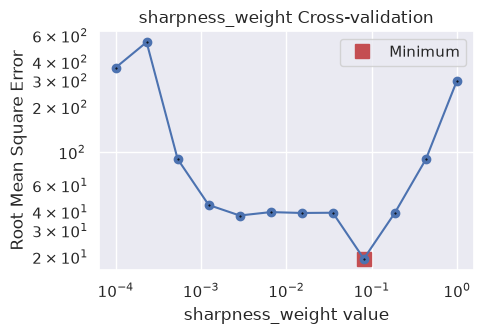

In [7]:
rng = np.random.default_rng(1)
constraints = pd.DataFrame(
    {
        "easting": rng.uniform(region[0] + 2000, region[1] - 2000, 15),
        "northing": rng.uniform(region[2] + 2000, region[3] - 2000, 15),
    }
)
constraints = invert4geom.sample_grids(
    constraints, true_topography, sampled_name="upward"
)

inv3 = invert4geom.Inversion(
    copy.deepcopy(data),
    copy.deepcopy(starting_model),
    solver_type="irls",
    sharpness_weight=0.01,
    max_iterations=100,
    l2_norm_tolerance=np.sqrt(gravity_noise),
    delta_l2_norm_tolerance=1.001,
)

inv3_best = inv3.optimize_inversion_sharpness(
    n_trials=12,
    sharpness_weight_limits=(1e-4, 1),
    constraints_df=constraints,
    grid_search=True,
    fname="tmp/sharpness_cv_constraints",
    plot_scores=True,
    progressbar=True,
)

print(
    f"best sharpness_weight (constraints scoring): "
    f"{inv3_best.best_trial.params['sharpness_weight']:.2e}"
)

The two scorings prefer weights roughly two orders of magnitude apart, and both are "right" for what they measure.
The gravity holdout finds the smallest weight that stops the inversion from fitting noise — beyond that, stronger regularization neither helps nor hurts the *gravity* prediction much, so its optimum sits low.
The constraint scoring instead measures the accuracy of the recovered *surface*, and for genuinely blocky geology like this fault, pushing the model harder towards blockiness keeps improving the surface until the regularization becomes so strong the data can no longer be fit (the sharp rise on the right of the curve).
When good constraints exist, their scoring targets what you actually care about; when they don't, the gravity holdout still protects you from under-regularizing.

## Final thoughts

- **`sharpness_weight` is the parameter to tune**, and the one with the largest effect on both the result and the run time: over-regularized inversions take far more iterations while removing less misfit per step. Search it in log space, and re-tune it whenever the data (noise level, spacing), the model (cell size, depth to the interface), or the density contrast change, since it balances quantities whose scales depend on all of these.
- **`sharpness_norm` is best fixed as a geological prior**, or cross-validated against constraint points. A gravity holdout cannot distinguish sharp from smooth models (that non-uniqueness is why regularization exists), so its score surface is nearly flat in the norm direction and the preferred norm is effectively decided by noise.
- **`irls_epsilon` rarely needs tuning**; include `irls_epsilon_limits` only if the recovered models show staircase artifacts (epsilon too small) or insufficient sharpening (too large) at the default.
- Watch the log for the **parameter-at-limits warning**: if the best value sits at the edge of your search range, widen the range and re-run.
- **The two scorings answer different questions and can prefer very different weights.** The gravity holdout finds the smallest weight that avoids fitting noise, protecting the *data* prediction; constraint scoring optimizes the accuracy of the recovered *surface*, and for blocky geology favors much stronger sharpening. Prefer constraint scoring when good constraints exist, and the gravity holdout otherwise.